> **Development/discovery log, not a tutorial.** For the tutorial version see `notebooks/tutorial_auror_scene.ipynb`; for the dated entry see `FINDINGS.md` ("2026-10-06 — Phase 5").

# The AUROR_ref scene from a static pose — minimum viable

This notebook re-runs a **received DIRSIG run tree**, `AUROR_ref/`, through dirfm against this
machine's DIRSIG install, and compares the result with the render that shipped with the tree.
The tree was built by someone else, on a Windows machine, with DIRSIG/scene2hdf
`2025.51 (822ab24)`. This install is `2026.38 (a020954)`. `AUROR_ref/` is reference material
only. It is gitignored, and nothing under it is modified: Stage 2 fingerprints the whole tree
around the render.

It follows `tutorial_tacoma_scene.ipynb`'s pattern. Most pieces already exist and are
**imported**, not rebuilt:

| Piece | Where it was built and checked | Here |
|---|---|---|
| Read-only scene reference (XML copy + asset symlinks) and the fingerprint guard | `tutorial_tacoma_scene.ipynb` (Phase 3) | `protodirsig.scene_ref`, **unchanged** |
| dirfm's `SCENE._fname` escape hatch | FINDINGS.md, Phase 3 | **unchanged** |
| Band coverage of a referenced scene's real materials | Phase 4b | `protodirsig.scene_coverage`, **extended** in this phase to follow bundle materials (Stage 0) |
| Subclass one dirfm class to emit DIRSIG XML/JSON that dirfm can't | `scripts/crosscheck_sgp4.py` (`Sgp4LocationEngine`) | the same move, three times (Stages 0–1) |

**What is new.** Five things: a `NewAtmosphere` plugin fed an existing database; a
`BasicPlatform` built from *existing* `.platform`/`.ppd`/`.tasks` files instead of dirfm objects;
`SpiceEphemeris` and `ThermWeather`; a scene with a `geometrylistinclude`d bundle object; and a
**single static pose**. There is no pass and no orbit propagation here, unlike the Tacoma notebook.
The sensor sits at one fixed point and renders one frame.

| Stage | What it does |
|---|---|
| 0 | Orientation: what the tree holds, what dirfm can and can't express (checked in the dirfm source and by calling it), and scene coverage |
| 1 | Reference and assemble every input, and diff the generated jsim against `AurorSimulation.jsim` |
| 2 | Render (fresh `scene2hdf` compile, fingerprint-guarded), then compare with the shipped `AurorNIROutput.img` / `truth1.img` |

---
# Stage 0 — Orientation and capability check

## Environment

This uses the same convention as the other notebooks. `DIRSIG_HOME` comes from the environment,
with this machine's install as the documented fallback, and its `bin/` is prepended to `PATH`.
`protodirsig` is imported from `src/`.

In [1]:
import os
import shutil
import sys
from pathlib import Path

DEFAULT_DIRSIG_HOME = Path.home() / "DIRSIG" / "dirsig-2026.38.0.a020954-Linux-x86_64"
DIRSIG_HOME = Path(os.environ.get("DIRSIG_HOME", DEFAULT_DIRSIG_HOME)).expanduser()
os.environ["DIRSIG_HOME"] = str(DIRSIG_HOME)
os.environ["PATH"] = f"{DIRSIG_HOME / 'bin'}{os.pathsep}" + os.environ.get("PATH", "")
assert shutil.which("scene2hdf") and shutil.which("dirsig5"), "DIRSIG binaries not on PATH"

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS = PROJECT / "outputs"
IN_DIR, OUT_DIR = OUTPUTS / "auror_scene_input", OUTPUTS / "auror_scene_output"

try:
    import protodirsig
except ImportError:
    sys.path.insert(0, str(PROJECT / "src"))
    import protodirsig

AUROR = PROJECT / "AUROR_ref"                            # read-only reference tree (gitignored)
print("DIRSIG_HOME :", DIRSIG_HOME)
print("protodirsig :", Path(protodirsig.__file__).parent)
print("AUROR_ref   :", AUROR, "exists" if (AUROR / "jsims" / "AurorSimulation.jsim").is_file() else "MISSING")
assert (AUROR / "jsims" / "AurorSimulation.jsim").is_file()

DIRSIG_HOME : /home/kevin-kearney/DIRSIG/dirsig-2026.38.0.a020954-Linux-x86_64
protodirsig : /home/kevin-kearney/dev/protoDIRSIG/src/protodirsig
AUROR_ref   : /home/kevin-kearney/dev/protoDIRSIG/AUROR_ref exists


## What the tree holds, read from the files

**A deviation from the plan, stated up front.** This phase's prompt says FINDINGS.md already
assessed the AUROR_ref tree's completeness, scene content and capability questions. **It does
not.** FINDINGS.md has no mention of AUROR or Tahoe; the only references in the repo are in
`prompt.md`. So every claim about the tree below is read from the tree's own files in this
notebook, not taken from earlier work.

The one surviving simulation file is `jsims/AurorSimulation.jsim`. The cell prints it as
received. It wires four plugins and one scene. Every path in it was written on the original
Windows machine, so it can't run here as-is. The cell sorts the paths into absolute Windows
paths, which must be rewritten, and relative ones.

In [2]:
import json

orig_jsim = json.loads((AUROR / "jsims" / "AurorSimulation.jsim").read_text())
assert len(orig_jsim) == 1
orig = orig_jsim[0]
PATH_KEYS = {"platform_filename", "motion_filename", "tasks_filename", "filename", "hdf_filename"}

print("plugins, in order:")
for p in orig["plugin_list"]:
    print(f"  {p['name']:15s} inputs: {sorted(p['inputs']) or '{}'}")
print("scene_list:", orig["scene_list"])
print("medium_list:", orig["medium_list"])

print("\npath-valued inputs:")
for p in orig["plugin_list"]:
    for k, v in p["inputs"].items():
        if k in PATH_KEYS:
            print(f"  {p['name']:15s} {k:18s} {v!r:72s} {'ABSOLUTE (Windows)' if ':' in v else 'relative'}")
for s in orig["scene_list"]:
    print(f"  {'scene_list':15s} {'inputs':18s} {s['inputs']!r:72s} ABSOLUTE (Windows)")

plugins, in order:
  BasicPlatform   inputs: ['motion_filename', 'platform_filename', 'split_channels', 'tasks_filename']
  NewAtmosphere   inputs: ['backend', 'hdf_filename', 'info']
  SpiceEphemeris  inputs: {}
  ThermWeather    inputs: ['filename']
scene_list: [{'inputs': 'C:/DIRSIG/AUROR/Kevin_DIRSIG/tahoe.scene'}]
medium_list: []

path-valued inputs:
  BasicPlatform   motion_filename    'C:/DIRSIG/AUROR/Kevin_DIRSIG/motion/AurorMotion.ppd'                    ABSOLUTE (Windows)
  BasicPlatform   platform_filename  'C:/DIRSIG/AUROR/Kevin_DIRSIG/platforms/AurorNIRDetector.platform'       ABSOLUTE (Windows)
  BasicPlatform   tasks_filename     'C:/DIRSIG/AUROR/Kevin_DIRSIG/tasks/AurorTask.tasks'                     ABSOLUTE (Windows)
  NewAtmosphere   hdf_filename       'AurorNewAtmosphere'                                                     relative
  ThermWeather    filename           'C:/DIRSIG/AUROR/Kevin_DIRSIG/weather/saw.wth'                           ABSOLUTE (Windows)
  scene

There are six path values, as the plan says, but not all of them are Windows paths. **Five are absolute Windows paths** under
`C:/DIRSIG/AUROR/Kevin_DIRSIG/`: the platform, motion, tasks and weather files, and the scene.
The sixth, the atmosphere's **`hdf_filename`, is not**. It is the bare relative name
`"AurorNewAtmosphere"`, which DIRSIG resolves against the jsim's own directory, `jsims/`. That
is where the file sits. Stage 1 places a copy so the generated jsim carries the same relative
value.

Which outputs belong to this jsim? `BasicPlatform` points at `AurorNIRDetector.platform`. That
file's capture `<basename>` is `AurorNIROutput`, and its one non-empty truth collection
(`Collection 1`, collector `GeoLocation`) writes `truth1`. So the reference pair for Stage 2 is
`jsims/AurorNIROutput.img` + `jsims/truth1.img`. They are the only `.img` files in `jsims/`
whose ENVI headers say DIRSIG `2025.51`. The others say `2026.01` and come from platforms with
no surviving jsim. The cell below checks both claims from the files. The plan described the
truth wiring as "`GeoLocation`→`NewCollection`". In the file, `GeoLocation` sits in
`Collection 1`. The nine `NewCollection` entries, plus one unnamed collection, all have
**empty** collector lists.

In [3]:
import re
import lxml.etree as et

plat = et.parse(str(AUROR / "platforms" / "AurorNIRDetector.platform")).getroot()
inst = plat.find(".//instrument")
fp = inst.find("focalplane")
cap = fp.find("capturemethod")
bp = cap.find("spectralresponse/bandpass")
ch = cap.find("spectralresponse/channellist/channel")
det = fp.find("detectorarray")
print(f"instrument   : {inst.get('name')!r}, focal length {inst.findtext('properties/focallength')} mm, "
      f"aperture {inst.findtext('properties/aperturediameter')} m")
print(f"bandpass     : {bp.findtext('minimum')}-{bp.findtext('maximum')} um @ {bp.findtext('delta')}; "
      f"channel {ch.get('name')!r} {ch.get('shape')} centre {ch.findtext('center')} um, width {ch.findtext('width')} um")
print(f"array        : {det.findtext('xelementcount')} x {det.findtext('yelementcount')} at "
      f"{det.findtext('xelementspacing')} um; clock {det.findtext('clock/rate')} Hz")
print(f"capture      : basename {cap.findtext('imagefile/basename')!r}, flux units "
      f"{cap.find('imagefile').get('fluxunits')!r}, integration {cap.findtext('temporalintegration/time')} s "
      f"x {cap.findtext('temporalintegration/samples')} samples, hypersampling "
      f"{cap.findtext('samplestrategy/hypersamplingmultiplier')}")
tcs = [(tc.findtext("name"), tc.findtext("imagefile/basename"), [c.findtext("name") for c in tc.iterfind("collectorlist/collector")])
       for tc in fp.iterfind("truthcollection")]
print(f"truth        : {len(tcs)} collections; non-empty: {[t for t in tcs if t[2]]}; "
      f"empty: {len([t for t in tcs if not t[2]])} (names {sorted({t[0] or '<unnamed>' for t in tcs if not t[2]})})")

print("\nENVI headers in jsims/:")
for hdr in sorted((AUROR / "jsims").glob("*.img.hdr")):
    h = hdr.read_text()
    ver = re.search(r"DIRSIG (\S+ \(\w+\))", h).group(1)
    dims = [re.search(rf"^{k}\s*=\s*(\d+)", h, re.M).group(1) for k in ("samples", "lines", "bands")]
    print(f"  {hdr.name:34s} DIRSIG {ver:18s} {'x'.join(dims)}")
assert cap.findtext("imagefile/basename") == "AurorNIROutput" and ("Collection 1", "truth1", ["GeoLocation"]) in tcs

instrument   : 'Auror NIR Detector', focal length 306 mm, aperture 0.085 m
bandpass     : 0.41-2 um @ 0.001; channel 'NIR Detector' gaussian centre 0.8500 um, width 0.06369914 um
array        : 500 x 500 at 10.000000 um; clock 1000 Hz
capture      : basename 'AurorNIROutput', flux units 'electronspersecond', integration 0.005 s x 10 samples, hypersampling 100
truth        : 11 collections; non-empty: [('Collection 1', 'truth1', ['GeoLocation'])]; empty: 10 (names ['<unnamed>', 'NewCollection'])

ENVI headers in jsims/:
  AurorNIROutput.img.hdr             DIRSIG 2025.51 (822ab24)  500x500x1
  MultiBandCamera_rgb.img.hdr        DIRSIG 2026.01 (822ab24)  256x256x3
  MultiBandCamera_rgb_truth.img.hdr  DIRSIG 2026.01 (822ab24)  256x256x9
  auror.img.hdr                      DIRSIG 2026.01 (822ab24)  500x500x2
  result.img.hdr                     DIRSIG 2026.01 (822ab24)  500x500x211
  truth1.img.hdr                     DIRSIG 2025.51 (822ab24)  500x500x6


## Capability check — read in the dirfm source, then called

The plan sets out a resolution for each of the four plugins. Each is checked here against
`dirfm/*.py` and by **calling** the code, not taken from the plan. Two of the plan's premises
fail.

**`NewAtmosphere` → `dirfm.atmosphere.NewAtmospherePlugin(fname)`.** The interface is as
described: `__init__(fname)` asserts that `fname` is an existing file, and
`get_plugin_inputs()` emits `{"info", "backend", "hdf_filename"}`. The backend comes from
`ModtranTapeBackend`'s setters `set_profile`, `set_atmospheric_model`,
`set_boundary_aerosol_model` and `set_multiple_scattering`, through `set_backend()`, with
`set_info()` filling `info`. **But none of those setters can be called as dirfm ships them.**
Every dirfm class inherits `_FrozenAttrs`. Once the outermost `__init__` returns, assigning any
attribute not already in the instance `__dict__` raises `AttributeError`.
`ModtranTapeBackend.__init__` never creates `_profile`, `_atmo_model`, `_multiple_scattering`
or `_boudary_aerosol_model`, and `NewAtmospherePlugin.__init__` never creates `_info` or
`_backend`. Those are exactly the attributes the setters assign. Separately,
`set_multiple_scattering` asserts its model is one of `["None", "Isacc", "Distort"]`.
`"Isacc"` is a typo. DIRSIG's backend manual (`docs/atm_backends.html`) and this jsim both spell
it **`"Isaac"`**, so the jsim's value is rejected. **`NewAtmospherePlugin` is not usable as
shipped. It is a wrapper with bugs, not a working one.**

**`SpiceEphemeris` → `dirfm.ephemeris`.** The jsim has `"inputs": {}`. dirfm's `SPICEPlugin`
**requires** three kernel paths (`spk`, `pck`, `lsk`), each asserted to be a `Path`, and always
emits all three. There is no zero-input form. The base `EphemerisPlugin` (via `Plugin`) does
emit `self._name` with `self._inputs = {}`, so a two-line subclass is enough.

**`BasicPlatform` → `PlatformSensorPlugin`.** As the plan says, `prepare()` always writes
`example.platform` from its Python attachments and calls `self._motion.write()` /
`self._tasks.write()`. No `_fname`-style short-circuit exists. **The plan's fix, a bare `Plugin`
subclass, does not survive `DIRSIG.write_files()`.** That method finds the platform by
`isinstance(p, PlatformSensorPlugin)` and then indexes `self._plugins[platform_plugin_idx]` for
its coverage loop. With no such plugin, the name is never bound. The cell shows this in a
throwaway directory. The fix keeps `crosscheck_sgp4.py`'s move, subclassing the dirfm class and
overriding only what must differ, but subclasses `PlatformSensorPlugin` itself. It has no
attachments, so dirfm's coverage loop has nothing to iterate. `prepare()` is a no-op, because
the files already exist, and `get_plugin_inputs()` returns the three paths plus the jsim's
`split_channels: false`.

**`ThermWeather` → `dirfm.weather.ThermWeatherFilePlugin(fname)`.** Works as described:
`{"filename": <relativized path>}`.

In [4]:
import inspect
from dirfm import DIRSIG, SCENE, atmosphere, ephemeris, weather
from dirfm.plugin import Plugin
from dirfm.platform_sensor import PlatformSensorPlugin


def attempt(label, fn):
    try:
        fn()
        print(f"  ok    {label}")
        return True
    except Exception as e:
        print(f"  FAILS {label}: {type(e).__name__}: {(str(e).splitlines() or ['(bare assert)'])[0][:110]}")
        return False


print("NewAtmospherePlugin signature:", inspect.signature(atmosphere.NewAtmospherePlugin.__init__))
print("its get_plugin_inputs keys   :", re.findall(r'"(\w+)":', inspect.getsource(atmosphere.NewAtmospherePlugin.get_plugin_inputs)))
print("ModtranTapeBackend setters   :", [n for n in vars(atmosphere.ModtranTapeBackend) if n.startswith("set_")])
print("multiple-scattering allowed  :", re.search(r'assert model in (\[.*?\])', inspect.getsource(atmosphere.ModtranTapeBackend.set_multiple_scattering)).group(1))

print("\ndirfm as shipped:")
b = atmosphere.ModtranTapeBackend()
shipped = [attempt("ModtranTapeBackend().set_profile('New Profile')", lambda: b.set_profile("New Profile")),
           attempt("ModtranTapeBackend().set_atmospheric_model('MidLatitudeSummer')", lambda: b.set_atmospheric_model("MidLatitudeSummer")),
           attempt("ModtranTapeBackend().set_multiple_scattering('Isaac')", lambda: b.set_multiple_scattering("Isaac"))]
na = atmosphere.NewAtmospherePlugin(AUROR / "jsims" / "AurorNewAtmosphere")
shipped += [attempt("NewAtmospherePlugin(...).set_info('', '', '', '')", lambda: na.set_info("", "", "", "")),
            attempt("NewAtmospherePlugin(...).get_plugin_inputs()", lambda: na.get_plugin_inputs())]
shipped += [attempt("ephemeris.SPICEPlugin()  (no kernels, as in the jsim)", lambda: ephemeris.SPICEPlugin())]
shipped += [attempt("weather.ThermWeatherFilePlugin(saw.wth).get_plugin_inputs()",
                    lambda: print("        ->", weather.ThermWeatherFilePlugin(AUROR / "weather" / "saw.wth").get_plugin_inputs()))]

print("\nPlatformSensorPlugin.prepare() writes:", re.findall(r'(dirs\["root"\] / "[^"]+"|self\._\w+\.write\(dirs\))',
                                                          inspect.getsource(PlatformSensorPlugin.prepare)))
print("DIRSIG.write_files() finds the platform by:",
      re.search(r"if (isinstance\(p,\s*PlatformSensorPlugin\))", inspect.getsource(DIRSIG.write_files)).group(1))


class BarePlatform(Plugin):                             # the plan's shape: name + inputs only
    def get_plugin_name(self):
        return "BasicPlatform"


probe_scene = SCENE("probe")
probe_scene._fname = AUROR / "tahoe.scene"               # never written or compiled: write_files() only
probe = DIRSIG(OUTPUTS / "auror_scene_probe_input", OUTPUTS / "auror_scene_probe_output")
probe.add_plugin(BarePlatform()).add_scene(probe_scene)
bare_ok = attempt("DIRSIG.write_files() with a bare Plugin as BasicPlatform", probe.write_files)
assert shipped == [False, False, False, False, False, False, True] and not bare_ok

Material [Dummy] ID has already been set to [N/A], can't override.


NewAtmospherePlugin signature: (self, fname)
its get_plugin_inputs keys   : ['info', 'backend', 'hdf_filename']
ModtranTapeBackend setters   : ['set_current_wind_speed', 'set_average_wind_speed', 'set_air_mass_influence', 'set_co2_mixing_ratio', 'set_visibility', 'set_band_model_name', 'set_profile', 'set_atmospheric_model', 'set_multiple_scattering', 'set_boundary_aerosol_model']
multiple-scattering allowed  : ["None","Isacc","Distort"]

dirfm as shipped:
  FAILS ModtranTapeBackend().set_profile('New Profile'): AttributeError: 'ModtranTapeBackend' object has no attribute '_profile'. Direct assignment of new attributes is disabled; use 
  FAILS ModtranTapeBackend().set_atmospheric_model('MidLatitudeSummer'): AttributeError: 'ModtranTapeBackend' object has no attribute '_atmo_model'. Direct assignment of new attributes is disabled; u
  FAILS ModtranTapeBackend().set_multiple_scattering('Isaac'): AssertionError: (bare assert)
  FAILS NewAtmospherePlugin(...).set_info('', '', '', ''): Att

That last call ran `write_files()` against the real `tahoe.scene` path. That is safe: with
`_fname` set, `SCENE.write()` returns the path without opening it, and `write_files()` failed
before writing a jsim. Nothing was compiled. Stage 2's fingerprint guard covers the whole tree in
any case.

### The resolutions, all inside protoDIRSIG (dirfm untouched)

* **`NewAtmosphere`.** Two subclasses whose `__init__` calls `super().__init__()` and then
  **pre-declares** the attributes the setters assign, before the freeze takes effect. After that,
  **dirfm's own setters run unchanged**: `set_profile`, `set_atmospheric_model`,
  `set_boundary_aerosol_model`, `set_backend` and `set_info`. Multiple scattering is the one
  exception. `set_multiple_scattering("Isaac")` cannot pass dirfm's typo'd assert, so the cell
  assigns exactly what that setter would have stored, `{"type": "Isaac", "parameters": {}}`. The
  setter does accept `"Isacc"`, but that would hand DIRSIG a misspelt model name, so it is not used.
* **`SpiceEphemeris`.** `EphemerisPlugin` with `_name = "SpiceEphemeris"` and no inputs.
* **`BasicPlatform`.** A `PlatformSensorPlugin` subclass that points at existing files (above).
* **`ThermWeather`.** `ThermWeatherFilePlugin`, unchanged.

**Reused unchanged from the Tacoma notebook:** the `SCENE._fname` reference,
`scene_ref.reference_scene` (XML copy + symlinked asset directories) and
`scene_ref.fingerprint`. **New here:** the four plugin resolutions above, the bundle inclusion
(next), and the single static pose.

In [5]:
from dirfm.atmosphere import ModtranTapeBackend, NewAtmospherePlugin
from dirfm.ephemeris import EphemerisPlugin
from dirfm.utilities.paths import relativize_path


class FixedModtranTapeBackend(ModtranTapeBackend):
    """dirfm's backend with the attributes its own setters assign declared before _FrozenAttrs freezes."""

    def __init__(self):
        super().__init__()
        self._profile = self._atmo_model = self._multiple_scattering = self._boudary_aerosol_model = None


class FixedNewAtmospherePlugin(NewAtmospherePlugin):
    """dirfm's NewAtmospherePlugin with `_info`/`_backend` declared, so set_info()/set_backend() work."""

    def __init__(self, fname):
        super().__init__(fname)
        self._info = self._backend = None


class NoInputSpiceEphemeris(EphemerisPlugin):
    """`SpiceEphemeris` with `inputs: {}` (DIRSIG's bundled kernels); dirfm's SPICEPlugin demands three paths."""

    def __init__(self):
        super().__init__()
        self._name = "SpiceEphemeris"


class PlatformFilesPlugin(PlatformSensorPlugin):
    """`BasicPlatform` over existing .platform/.ppd/.tasks files. A PlatformSensorPlugin (with no
    attachments) because DIRSIG.write_files() requires one; prepare() writes nothing."""

    def __init__(self, platform, motion, tasks, split_channels=False):
        super().__init__()
        self._files = {"platform_filename": platform, "motion_filename": motion, "tasks_filename": tasks}
        self._split = split_channels

    def prepare(self, dirs):
        assert all(p.is_file() for p in self._files.values())

    def get_plugin_inputs(self, dirs=None):
        render = (lambda p: relativize_path(dirs, p, "root")) if dirs is not None else (lambda p: p.as_posix())
        return {**{k: render(p) for k, p in self._files.items()}, "split_channels": self._split}


print("with the subclasses:")
fb = FixedModtranTapeBackend()
fixed = [attempt("set_profile / set_atmospheric_model / set_boundary_aerosol_model",
                 lambda: fb.set_profile("New Profile").set_atmospheric_model("MidLatitudeSummer").set_boundary_aerosol_model("RuralVis23Km")),
         attempt("set_multiple_scattering('Isaac')  (still the typo'd assert)", lambda: fb.set_multiple_scattering("Isaac"))]
fb._multiple_scattering = {"type": "Isaac", "parameters": {}}   # what that setter stores, with DIRSIG's spelling
fn = FixedNewAtmospherePlugin(AUROR / "jsims" / "AurorNewAtmosphere")
fixed += [attempt("set_info / set_backend / get_plugin_inputs()",
                  lambda: print("        ->", fn.set_info("", "", "", "").set_backend(fb).get_plugin_inputs()["backend"]))]
fixed += [attempt("NoInputSpiceEphemeris()", lambda: print("        ->", NoInputSpiceEphemeris().get_plugin_name(), NoInputSpiceEphemeris().get_plugin_inputs()))]
assert fixed == [True, False, True, True]

with the subclasses:
  ok    set_profile / set_atmospheric_model / set_boundary_aerosol_model
  FAILS set_multiple_scattering('Isaac')  (still the typo'd assert): AssertionError: (bare assert)
        -> {'name': 'modtran_tape', 'modtran_profile': 'New Profile', 'tape5_parameters': {'atmospheric_model': 'MidLatitudeSummer', 'multiple_scattering': {'type': 'Isaac', 'parameters': {}}, 'boundary_aerosol_model': {'type': 'RuralVis23Km', 'parameters': {}}}}
  ok    set_info / set_backend / get_plugin_inputs()
        -> SpiceEphemeris {}
  ok    NoInputSpiceEphemeris()


## The scene, checked against its files

`tahoe.scene` is **not** the Tahoe configuration used elsewhere in this project. The cell
below reads the scene and its includes and prints what each claim rests on. The claims:

* `features="vis,nir,swir,sources,exoatm"`, with no `mwir`.
* The geometry is `lists/terrain.glist` (one OBJ terrain, `objects/small.obj`) **plus**
  `lists/hypersonic.glist`. That second list instances the bundle
  `bundles/hypersonic/hypersonic.glist`, a ~2 m OBJ with **local** materials (`hypersonic.mat`,
  material `Gidder_mat`), on a `dynamicinstance`. Its `straight` location engine starts at scene
  `(-400, 400, 50000)`, 50 km up, heading 90° at 100 m/s. A `staticinstance` copy in
  `hypersonic_old.glist` is not referenced by the scene.
* `Gidder_mat` is `SimpleReflectance` with **zero** reflectance (`ref.txt`) and a `DataDriven`
  temperature of **1500 K**, so the vehicle is a hot blackbody. This is not a reflective target.
* **Both maps are disabled** (`materialmap` and `texturemap`, `enabled="false"`). The terrain
  OBJ has a single `usemtl 1`, so the whole terrain is material 1, "Terrain (proxy)", with
  `gray.ems` (flat 0.90 emissivity, 0.2–20 µm).

So this is not a land-classification scene. It is uniform grey terrain under a hot object at
50 km, viewed by a NIR sensor overhead. That is consistent with a **single-target
detection/geolocation run**. The disabled maps and the missing `mwir` fit that purpose, and are
**not treated as something to fix**. (This is this notebook's reading of the files. As noted
above, FINDINGS.md had no prior assessment to defer to.)

**The motion is one fixed pose, not a pass.** `AurorMotion.ppd` has a single `<entry>`: position
scene `(-400, 400, 550000)` (550 km straight up, in the `sceneenu` frame), Euler angles
`(0, 0, π)`. That puts the sensor **500 km directly above the vehicle**. The tasks file's one
task starts and stops at relative time 0. **This notebook renders one fixed geometry.** There is
no trajectory, and Stage 2 makes no pass-dependent claim.

**Two inconsistencies, flagged rather than fixed:**

* **The reference datetime is `2009-07-27T11:29:32.0000-08:00`**, 17 years older than every
  file in the tree (2026 mtimes), and `-08:00` is PST, while Tahoe in July is on PDT (`-07:00`).
  It is used as given.
* **The atmosphere database was not built for this scene.** `AurorNewAtmosphere`'s HDF root
  attributes give its origin as **43.12° N, −78.45° E, 250 m** (western New York), against the
  scene's 39° N, −120° E, 0 m. Its stored solar geometry matches that origin at the task time,
  not Tahoe. The cell recomputes both with skyfield. The original run used the same file, so a
  like-for-like comparison is still valid, but the absolute radiometry is not "Tahoe at
  11:29 PST".

In [6]:
import h5py
import numpy as np
from datetime import datetime, timedelta, timezone
from skyfield.api import Loader, wgs84

scene_xml = et.parse(str(AUROR / "tahoe.scene")).getroot()
loc = scene_xml.find("sceneorigin/location")
LAT0, LON0, ALT0 = (float(loc.findtext(k)) for k in ("latitude", "longitude", "altitude"))
print(f"scene origin : {LAT0}, {LON0}, {ALT0} m;  features = {scene_xml.find('properties').get('features')!r}")
print("includes     :", [(g.text, g.get("enabled")) for g in scene_xml.iterfind("geometrylist/geometrylistinclude")])
print("maps         :", [(m.tag, m.get("name"), m.get("enabled")) for m in scene_xml.find("maplist")])
geo = AUROR / "geometry"
print("terrain OBJ  : usemtl", sorted({ln.split()[1] for ln in (geo / "objects" / "small.obj").open() if ln.startswith("usemtl")}))

hl = et.parse(str(geo / "lists" / "hypersonic.glist")).getroot()
le = hl.find(".//dynamicinstance/motion/locationengine")
start = [float(le.findtext(f"start/{a}")) for a in "xyz"]
bundle_glist = et.parse(str(geo / hl.findtext(".//basegeometry/glist/filename"))).getroot()   # gdbdirectory-relative
print(f"vehicle      : {hl.findtext('.//basegeometry/glist/filename')} (search_paths="
      f"{bundle_glist.find('object').get('search_paths')!r}, localmaterials {bundle_glist.findtext('object/localmaterials')!r}); "
      f"{le.get('type')} engine from {start}, heading {le.findtext('heading')} deg at {le.findtext('velocity')} m/s")
gm = (geo / "bundles" / "hypersonic" / "hypersonic.mat").read_text()
print("Gidder_mat   :", re.findall(r"(REFLECTANCE_PROP_NAME = \S+|TXT_FILENAME = \S+|TEMP_SOLVER_NAME = \S+|TEMPERATURE += \S+)", gm),
      "; ref.txt values", sorted({float(ln.split()[1]) for ln in (geo / "bundles" / "hypersonic" / "ref.txt").read_text().split("\n") if ln.strip()}))
v = np.array([[float(x) for x in ln.split()[1:4]] for ln in (geo / "bundles" / "hypersonic" / "hypersonic.obj").open() if ln.startswith("v ")])
print(f"vehicle size : {np.ptp(v, axis=0).round(2)} m")

mo = et.parse(str(AUROR / "motion" / "AurorMotion.ppd")).getroot()
entries = mo.findall("data/entry")
SENSOR = [float(entries[0].findtext(f"position/location/point/{a}")) for a in "xyz"]
EULER = [float(entries[0].findtext(f"orientation/eulerangles/cartesiantriple/{a}")) for a in "xyz"]
print(f"\nmotion       : {len(entries)} entry; frame {mo.find('data').get('rotationframe')!r}, "
      f"position {SENSOR}, euler {EULER} rad")
tk = et.parse(str(AUROR / "tasks" / "AurorTask.tasks")).getroot()
REF_DT = tk.findtext("reference/datetime")
print(f"tasks        : reference {REF_DT}; {len(tk.findall('task'))} task, start {tk.findtext('task/start/datetime')} "
      f"stop {tk.findtext('task/stop/datetime')} (relative s)")
print(f"sensor - vehicle start = {np.subtract(SENSOR, start)} m")

with h5py.File(AUROR / "jsims" / "AurorNewAtmosphere", "r") as f:
    atm_origin = f.attrs["Wgs84LatLonAltOrigin"]
    atm_ref = f["TemporalStates"].attrs["ReferenceDateTime"][0]
    atm_alts = f["Altitudes"][()]
    st = f["State0"].attrs
    atm_sun = (float(st["SolarZenith"][0]), float(st["SolarAzimuth"][0]))
    wl = f["SpectralStates/WavelengthSamplesTable"][0]
print(f"\natmosphere DB: origin {atm_origin}, reference {atm_ref!r}, altitudes {atm_alts} m, "
      f"{wl.min():.2f}-{wl.max():.2f} um; stored sun zenith/azimuth {atm_sun[0]:.2f}/{atm_sun[1]:.2f} deg")
load = Loader(OUTPUTS / "_orbit_data", verbose=False)
eph = load("de421.bsp")
t_task = load.timescale().from_datetime(datetime.fromisoformat(REF_DT.replace(".0000", "")))
for name, (la, lo) in {"scene origin (Tahoe)": (LAT0, LON0), "atmosphere DB origin": tuple(atm_origin[:2])}.items():
    alt_, az_, _ = (eph["earth"] + wgs84.latlon(la, lo)).at(t_task).observe(eph["sun"]).apparent().altaz()
    print(f"  sun at {name:21s}: zenith {90 - alt_.degrees:6.2f}, azimuth {az_.degrees:6.2f} deg")
assert len(entries) == 1 and np.allclose(np.subtract(SENSOR, start), [0, 0, 500000])
assert scene_xml.find("properties").get("features") == "vis,nir,swir,sources,exoatm"
assert all(m.get("enabled") == "false" for m in scene_xml.find("maplist"))

scene origin : 39.0, -120.0, 0.0 m;  features = 'vis,nir,swir,sources,exoatm'
includes     : [('lists/terrain.glist', 'true'), ('lists/hypersonic.glist', 'true')]
maps         : [('materialmap', 'Tahoe Class Map (small)', 'false'), ('texturemap', 'Tahoe Texture Map (small)', 'false')]
terrain OBJ  : usemtl ['1']
vehicle      : bundles/hypersonic/hypersonic.glist (search_paths='local', localmaterials 'hypersonic.mat'); straight engine from [-400.0, 400.0, 50000.0], heading 90 deg at 100 m/s
Gidder_mat   : ['TEMP_SOLVER_NAME = DataDriven', 'TEMPERATURE = 1500', 'REFLECTANCE_PROP_NAME = SimpleReflectance', 'TXT_FILENAME = ref.txt'] ; ref.txt values [0.0]


vehicle size : [2.   0.99 0.29] m

motion       : 1 entry; frame 'sceneenu', position [-400.0, 400.0, 550000.0], euler [0.0, 0.0, 3.141592654] rad
tasks        : reference 2009-07-27T11:29:32.0000-08:00; 1 task, start 0 stop 0 (relative s)
sensor - vehicle start = [     0.      0. 500000.] m

atmosphere DB: origin [ 43.12 -78.45 250.  ], reference '2009-07-27T11:29:32.0000-08:00', altitudes [    0. 45000. 50000.] m, 0.41-2.00 um; stored sun zenith/azimuth 36.24/238.56 deg


  sun at scene origin (Tahoe) : zenith  21.50, azimuth 155.52 deg
  sun at atmosphere DB origin : zenith  36.27, azimuth 238.63 deg


## Band coverage — `scene_coverage`, extended to bundle materials

The sensor band is 0.41–2.0 µm. dirfm's own coverage check is vacuous for a `_fname` scene
(FINDINGS.md, Phase 3), so Phase 4b's `protodirsig.scene_coverage` is the check. **The plan
asked whether it handles a `geometrylistinclude`-contributed material like `Gidder_mat`. It did
not.** It read only the `.scene`'s `<matfilename>`. On this scene it reported 10 materials, all
covering 0.41–2.0 µm, and **`covers(0.41, 2.0) == True` without ever seeing the one material
the target is made of.** That is a fail-*open* result from a helper built to fail closed. The
same gap applied to Tacoma: its `targets.glist` brings in two bundles (`tribar`, `helicopter`)
with six local materials. Those happen to be wavelength-independent Ward BRDFs, so Tacoma's
Phase 4b verdicts were right by luck, not by construction.

**Extended in this phase** (`src/protodirsig/scene_coverage.py`, pinned by
`tests/test_scene_coverage.py`):

* follow every enabled `.glist` `geometrylistinclude`, recursively through
  `<basegeometry><glist>`, and parse each `<localmaterials>` file. Resolution honours
  `search_paths="local"` (relative to the glist) versus the default scene search paths, as
  `docs/glist.html` describes. A missing include, bundle glist or `.mat` becomes an *unknown*
  material, so the check fails closed;
* `SimpleReflectance` / `TXT_FILENAME`, a two-column wavelength/reflectance table;
* a `MATERIAL_MAP` proxy (Tacoma's `TriBarTarget`) takes the intersection of its LUT targets'
  spans. Its `IMAGE_FILENAME` is a class map, not spectral data;
* disabled texture maps are no longer listed.

Tacoma's pinned results are unchanged: 42 scene materials, span (0.40, 0.78), covers 0.4–0.7,
and not 0.4–0.9. The six bundle materials are now counted as well.

In [7]:
from protodirsig.scene_coverage import scene_coverage

BAND = (float(bp.findtext("minimum")), float(bp.findtext("maximum")))
cov = scene_coverage(AUROR / "tahoe.scene")              # read-only: parses files, writes nothing
print(f"{cov.mat_file.name}: {sum(m.source == cov.mat_file for m in cov.materials)} scene materials; "
      f"bundles: {[str(p.relative_to(AUROR)) for p in cov.bundle_mats]}; unknown: {len(cov.unknown)}")
for m in cov.materials:
    print(f"  {m.id:>10s}  {m.name:22s} {m.props[0] if m.props else '-':18s} "
          f"{', '.join(f'{f} {lo:.2f}-{hi:.2f}' for f, (lo, hi, _) in m.files.items()):34s} "
          f"{'<- ' + m.source.parent.name + '/' + m.source.name if m.source != cov.mat_file else ''}")
print(f"\nband covered by every material: {cov.span[0]:.2f}-{cov.span[1]:.2f} um; covers sensor band {BAND}: {cov.covers(*BAND)}")
print(f"enabled texture maps: {cov.texture_bands or 'none'}")
assert any(m.id == "Gidder_mat" for m in cov.materials) and cov.covers(*BAND) and not cov.unknown

tahoe.mat: 10 scene materials; bundles: ['geometry/bundles/hypersonic/hypersonic.mat']; unknown: 0
           1  Terrain (proxy)        ClassicEmissivity  emissivity/gray.ems 0.20-20.00     
          11  Water                  ClassicEmissivity  emissivity/class1.ems 0.40-15.60   
          12  Class #2               ClassicEmissivity  emissivity/class2.ems 0.40-15.60   
          13  Class #3               ClassicEmissivity  emissivity/class3.ems 0.40-15.60   
          14  Class #4 (asphalt)     ClassicEmissivity  emissivity/class4.ems 0.40-15.60   
          15  Class #5 (grass)       ClassicEmissivity  emissivity/class5.ems 0.40-15.60   
          16  Class #6 (coniferous)  ClassicEmissivity  emissivity/class6.ems 0.40-15.60   
          17  Class #7 (Pine Tree)   ClassicEmissivity  emissivity/class7.ems 0.40-15.60   
          18  Class #8               ClassicEmissivity  emissivity/class8.ems 0.40-15.60   
          19  Class #9 (concrete)    ClassicEmissivity  emissivity/class9

**Result.** Every material covers the sensor band. The narrowest span is `Gidder_mat`'s
0.40–3.0 µm, and `.ems` curves run 0.40–15.6 µm. The vehicle's material is now in the report.
Before this phase's extension it was invisible to the helper.

---
# Stage 1 — Reference and assemble

## Where every input lives

Nothing under `AUROR_ref/` is referenced by a path that DIRSIG could write beside. The Tacoma
lesson (FINDINGS.md, Phase 3) is that **`scene2hdf` writes `<scene>.hdf` next to the `.scene`
it is given**, even through a symlink. The receiving directory, `outputs/auror_scene_input/`
(dirfm's `in_root`), is laid out to mirror the original tree:

```
outputs/auror_scene_input/
  auror_ref/tahoe.scene        copy of the 3.4 KB XML (asserted byte-identical)
  auror_ref/{geometry,materials,maps} -> symlinks into AUROR_ref/   (read in place via $SCENE_DIR)
  platforms/AurorNIRDetector.platform, motion/AurorMotion.ppd,
  tasks/AurorTask.tasks, weather/saw.wth                            copies (asserted byte-identical)
  AurorNewAtmosphere           copy of the 8.6 MB atmosphere database, next to the jsim
  example.jsim                 written by dirfm
```

The scene goes through `scene_ref.reference_scene` **unchanged**. `tahoe.scene` resolves every
asset through `$SCENE_DIR/geometry`, `$SCENE_DIR/materials` and `$SCENE_DIR/maps`, the same
three directories the helper symlinks by default. That includes the bundle, which sits under
`geometry/bundles/`. The other five files are copied rather than referenced in place. That keeps
the job self-contained, gives every path in the jsim a relative form like the original's
`hdf_filename`, and means nothing DIRSIG might do to an input (the atmosphere database is an
HDF5 file that `atm_builder` writes to) can reach `AUROR_ref/`. None of these copies is
modified.

## The four plugins, in the jsim's order

* `BasicPlatform`: `PlatformFilesPlugin` (Stage 0) over the copied platform, motion and tasks
  files, `split_channels=False`.
* `NewAtmosphere`: `FixedNewAtmospherePlugin(copy of AurorNewAtmosphere)`. Its backend is
  rebuilt from the jsim's inline `modtran_tape` block with dirfm's setters: `set_profile("New
  Profile")`, `set_atmospheric_model("MidLatitudeSummer")`,
  `set_boundary_aerosol_model("RuralVis23Km")`, then `set_backend()` and `set_info("", "", "",
  "")`. Multiple scattering is `"Isaac"`, assigned as in Stage 0. This backend block does not
  drive the render. Per `docs/newatm_plugin.html`, it is the recipe `atm_builder` uses to
  *build* the database, which here already exists. It is reconstructed so the generated jsim
  says what the original said.
* `SpiceEphemeris`: `NoInputSpiceEphemeris()`.
* `ThermWeather`: `ThermWeatherFilePlugin(copy of saw.wth)`.

The cell assembles everything on a `DIRSIG` object and calls `write_files()`, which builds the
`JSIM` (and creates the empty dirfm subdirectories) **without** compiling or rendering. It then
diffs the result against `AurorSimulation.jsim` key by key. Path values are compared by
**target**: the original's Windows file name must equal ours, and our file must be
byte-identical to the one in `AUROR_ref/`. Every other value is compared exactly.

In [8]:
import filecmp
from pathlib import PureWindowsPath
from dirfm import DIRSIG, SCENE
from dirfm.weather import ThermWeatherFilePlugin
from protodirsig.scene_ref import fingerprint, reference_scene

if IN_DIR.exists():
    shutil.rmtree(IN_DIR)                 # our own output dir; rmtree unlinks symlinks, never follows them
IN_DIR.mkdir(parents=True)

REF_DIR = IN_DIR / "auror_ref"
ref_file = reference_scene(AUROR / "tahoe.scene", REF_DIR)      # XML copy + geometry/materials/maps symlinks
auror_scene = SCENE("tahoe")
auror_scene._fname = ref_file                                    # private attribute: write() returns it as-is

copies = {}
for rel in ["platforms/AurorNIRDetector.platform", "motion/AurorMotion.ppd", "tasks/AurorTask.tasks",
            "weather/saw.wth", "jsims/AurorNewAtmosphere"]:
    dst = IN_DIR / (Path(rel).name if rel.startswith("jsims/") else rel)   # the database sits beside the jsim
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(AUROR / rel, dst)
    assert filecmp.cmp(AUROR / rel, dst, shallow=False)
    copies[Path(rel).name] = dst

backend = (FixedModtranTapeBackend().set_profile("New Profile").set_atmospheric_model("MidLatitudeSummer")
           .set_boundary_aerosol_model("RuralVis23Km"))
backend._multiple_scattering = {"type": "Isaac", "parameters": {}}   # dirfm's setter asserts the typo "Isacc"

job = DIRSIG(IN_DIR, OUT_DIR)
job.add_plugin(PlatformFilesPlugin(copies["AurorNIRDetector.platform"], copies["AurorMotion.ppd"],
                                   copies["AurorTask.tasks"], split_channels=False))
job.add_plugin(FixedNewAtmospherePlugin(copies["AurorNewAtmosphere"]).set_backend(backend).set_info("", "", "", ""))
job.add_plugin(NoInputSpiceEphemeris())
job.add_plugin(ThermWeatherFilePlugin(copies["saw.wth"]))
job.add_scene(auror_scene, [0, 0, 0])

assembled = job.write_files()                 # builds the JSIM; no scene2hdf, no dirsig5
assembled.write(IN_DIR / "assembled.jsim")
ours = json.loads((IN_DIR / "assembled.jsim").read_text())[0]
print(f"scene reference : {ref_file.relative_to(PROJECT)}  (symlinks: "
      f"{sorted(p.name for p in REF_DIR.iterdir() if p.is_symlink())})")
print(json.dumps(ours, indent=1)[:2400])

Material [Dummy] ID has already been set to [N/A], can't override.


scene reference : outputs/auror_scene_input/auror_ref/tahoe.scene  (symlinks: ['geometry', 'maps', 'materials'])
{
 "scene_list": [
  {
   "inputs": "auror_ref/tahoe.scene",
   "offset": "0,0,0"
  }
 ],
 "plugin_list": [
  {
   "name": "BasicPlatform",
   "inputs": {
    "platform_filename": "platforms/AurorNIRDetector.platform",
    "motion_filename": "motion/AurorMotion.ppd",
    "tasks_filename": "tasks/AurorTask.tasks",
    "split_channels": false
   }
  },
  {
   "name": "NewAtmosphere",
   "inputs": {
    "info": {
     "name": "",
     "author": "",
     "organization": "",
     "description": ""
    },
    "backend": {
     "name": "modtran_tape",
     "modtran_profile": "New Profile",
     "tape5_parameters": {
      "atmospheric_model": "MidLatitudeSummer",
      "multiple_scattering": {
       "type": "Isaac",
       "parameters": {}
      },
      "boundary_aerosol_model": {
       "type": "RuralVis23Km",
       "parameters": {}
      }
     }
    },
    "hdf_filename": "Au

In [9]:
def flat(d, prefix=""):
    out = {}
    for k, v in d.items():
        if isinstance(v, dict) and v:
            out.update(flat(v, f"{prefix}{k}."))
        else:
            out[f"{prefix}{k}"] = v
    return out


def source_of(win_path):
    """The AUROR_ref file a C:/DIRSIG/AUROR/Kevin_DIRSIG/... (or jsim-relative) path names."""
    parts = PureWindowsPath(win_path).parts
    return AUROR.joinpath(*parts[parts.index("Kevin_DIRSIG") + 1:]) if "Kevin_DIRSIG" in parts else AUROR / "jsims" / win_path


diffs, rewrites = [], []
assert [p["name"] for p in ours["plugin_list"]] == [p["name"] for p in orig["plugin_list"]], "plugin order differs"
pairs = [(p["name"], flat(o["inputs"]), flat(p["inputs"])) for o, p in zip(orig["plugin_list"], ours["plugin_list"])]
pairs.append(("scene_list[0]", flat(orig["scene_list"][0]), flat(ours["scene_list"][0])))
for name, a, b in pairs:
    for key in sorted(a.keys() | b.keys()):
        leaf = key.split(".")[-1]
        if key not in b:
            diffs.append((name, key, "only in original", a[key]))
        elif key not in a:
            diffs.append((name, key, "only in ours", b[key]))
        elif leaf in PATH_KEYS or name.startswith("scene_list") and key == "inputs":
            src, dst = source_of(a[key]), IN_DIR / b[key]
            same = PureWindowsPath(a[key]).name == Path(b[key]).name and filecmp.cmp(src, dst, shallow=False)
            rewrites.append((name, key, a[key], b[key], same))
        elif a[key] != b[key]:
            diffs.append((name, key, "differs", (a[key], b[key])))

print("path rewrites (original -> ours; ours is a byte-identical copy of the original's target):")
for name, key, a_, b_, same in rewrites:
    print(f"  {name:14s} {key:18s} {a_:62s} -> {b_:38s} {'identical' if same else 'MISMATCH'}")
print("\nevery other difference:")
for d in diffs:
    print(f"  {d[0]:14s} {d[1]:44s} {d[2]:17s} {d[3]!r}")

EXPECTED = {("NewAtmosphere", "backend.extract_profile", "only in original", False),
            ("NewAtmosphere", "backend.tape5_parameters.multiple_scattering.parameters", "only in ours", "{}"),
            ("scene_list[0]", "offset", "only in ours", "0,0,0")}
assert len(rewrites) == 6 and all(r[-1] for r in rewrites)
assert {(n, k, w, v if not isinstance(v, dict) else json.dumps(v)) for n, k, w, v in diffs} == EXPECTED

path rewrites (original -> ours; ours is a byte-identical copy of the original's target):
  BasicPlatform  motion_filename    C:/DIRSIG/AUROR/Kevin_DIRSIG/motion/AurorMotion.ppd            -> motion/AurorMotion.ppd                 identical
  BasicPlatform  platform_filename  C:/DIRSIG/AUROR/Kevin_DIRSIG/platforms/AurorNIRDetector.platform -> platforms/AurorNIRDetector.platform    identical
  BasicPlatform  tasks_filename     C:/DIRSIG/AUROR/Kevin_DIRSIG/tasks/AurorTask.tasks             -> tasks/AurorTask.tasks                  identical
  NewAtmosphere  hdf_filename       AurorNewAtmosphere                                             -> AurorNewAtmosphere                     identical
  ThermWeather   filename           C:/DIRSIG/AUROR/Kevin_DIRSIG/weather/saw.wth                   -> weather/saw.wth                        identical
  scene_list[0]  inputs             C:/DIRSIG/AUROR/Kevin_DIRSIG/tahoe.scene                       -> auror_ref/tahoe.scene                  identical

e

**The generated jsim matches `AurorSimulation.jsim` apart from the path rewrite and three
differences, each explained:**

* **The six paths.** Each was rewritten to a relative path under `outputs/auror_scene_input/`,
  and each points at a byte-identical copy of the original's target. `hdf_filename` is
  `"AurorNewAtmosphere"` in both, because the copy sits beside our jsim just as the original sat
  in `jsims/`.
* **`backend.extract_profile: false` is only in the original.** dirfm's `ModtranTapeBackend`
  has no setter for it, and `write()` never emits it. `docs/atm_backends.html` says the option is
  *"disabled by default"*, so leaving it out means the same thing. And as noted above, the
  backend block is the recipe for building the database, which is not rebuilt here.
* **`multiple_scattering.parameters: {}` is only in ours.** That is the shape dirfm's setter
  stores. DIRSIG's own example in the same manual writes `"parameters": {}` for `"Isaac"`.
* **`scene_list[0].offset: "0,0,0"` is only in ours.** dirfm's `JSIM.write()` always emits an
  offset. Zero is the no-offset case.

Key order inside objects differs (dirfm writes `scene_list` first), which JSON does not treat as
meaningful. Plugin order matches, which the cell asserts.

**What did not happen.** dirfm's coverage check didn't run. `PlatformFilesPlugin` has no
attachments, so `write_files()`'s per-focal-plane loop had nothing to iterate. That is
intentional. That check is vacuous for a `_fname` scene anyway (Phase 3), and Stage 0's
`scene_coverage` result is the one that counts.

---
# Stage 2 — Run and compare

## The run

`job.run()` repeats `write_files()`, writes `example.jsim`, runs `scene2hdf` on
`auror_ref/tahoe.scene`, and then runs `dirsig5`. No seed and no convergence flags are passed,
because the original jsim used neither. Around the call, the cell:

* fingerprints **all of `AUROR_ref/`** (path, size, mtime, mode) and asserts nothing changed,
  using `scene_ref.fingerprint`, unchanged from the Tacoma notebook;
* asserts the scene HDF is a **fresh compile**. `auror_ref/` starts with no `tahoe.scene.hdf`,
  and afterwards it must hold one written during this run, by the `scene2hdf` whose version the
  log reports. The shipped 25.7 MB `AUROR_ref/tahoe.scene.hdf` from `2025.51` is never
  referenced. It is not compared byte for byte: two compiles of this scene by this same install,
  made while building this notebook, already produced different hashes, so a hash says nothing
  about the version;
* records dirfm's log, which carries `scene2hdf`'s and `dirsig5`'s stdout and stderr, and
  pulls out version lines and warnings.

In [10]:
import logging
import subprocess
import time


class Capture(logging.Handler):
    def __init__(self):
        super().__init__(logging.DEBUG); self.records = []
    def emit(self, record):
        self.records.append(record.getMessage())


cap_log = Capture()
dirfm_log = logging.getLogger("dirfm")
dirfm_log.addHandler(cap_log); dirfm_log.setLevel(logging.INFO)

assert not (REF_DIR / "tahoe.scene.hdf").exists()
before = fingerprint(AUROR)
wall0, t0 = time.time(), time.perf_counter()
job.run()
elapsed = time.perf_counter() - t0
after = fingerprint(AUROR)
dirfm_log.removeHandler(cap_log)

new_hdf, old_hdf = REF_DIR / "tahoe.scene.hdf", AUROR / "tahoe.scene.hdf"
print(f"run() {elapsed:.0f} s")
print(f"AUROR_ref fingerprint : {len(before)} paths, unchanged = {before == after}")
print(f"scene2hdf wrote       : {sorted(p.name for p in REF_DIR.iterdir() if not p.is_symlink())}")
print(f"scene HDF  ours       : {new_hdf.relative_to(PROJECT)}, {new_hdf.stat().st_size / 1e6:.2f} MB, written by this run")
print(f"           shipped    : {old_hdf.relative_to(PROJECT)}, {old_hdf.stat().st_size / 1e6:.2f} MB (not referenced)")
versions = sorted(set(re.findall(r"Version: (\S+ \(\w+\))", log := "\n".join(cap_log.records))))
print("versions in the scene2hdf/dirsig5 logs:", versions)
(IN_DIR / "run.log").write_text(log)                     # full scene2hdf + dirsig5 output, for reference
warn_blocks, cur = [], None
for ln in log.splitlines():
    msg = ln.split("[warn]", 1)[1].strip() if ln.lstrip().startswith("[warn]") else None
    if msg is not None and cur is not None and " " not in msg:     # a list item continuing the last warning
        cur.append(msg)
    elif msg is not None:
        cur = [msg]; warn_blocks.append(cur)
    else:
        cur = None
print(f"dirsig5 warnings ({len(warn_blocks)}):")
for b in warn_blocks:
    print("  " + b[0][:160] + (f"  [+ {', '.join(b[1:])}]" if len(b) > 1 else ""))
print("outputs   :", sorted(p.name for p in OUT_DIR.iterdir()))
assert before == after, "AUROR_ref changed during the run"
assert new_hdf.is_file() and new_hdf.stat().st_mtime >= wall0 - 1     # written by this run
assert versions == ["2026.38 (a020954)"]

run() 353 s
AUROR_ref fingerprint : 68 paths, unchanged = True
scene2hdf wrote       : ['asset_report.txt', 'tahoe.scene', 'tahoe.scene.hdf']
scene HDF  ours       : outputs/auror_scene_input/auror_ref/tahoe.scene.hdf, 25.67 MB, written by this run
           shipped    : AUROR_ref/tahoe.scene.hdf, 25.67 MB (not referenced)
versions in the scene2hdf/dirsig5 logs: ['2026.38 (a020954)']
dirsig5 warnings (13):
  ../../AUROR_ref/materials/emissivity/class1.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
  ../../AUROR_ref/materials/emissivity/class2.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
  ../../AUROR_ref/materials/emissivity/class3.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550μm
  ../../AUROR_ref/materials/emissivity/class4.ems: has wavelengths 0.400-15.600μm, but this is insufficient for the scene wavelengths 0.350-2.550

## A same-version baseline

To call any ours-vs-reference difference "expected", we need to know how much an identical run
on **this** version varies. The cell re-runs `dirsig5` on the same `example.jsim` (the compiled
scene HDF is reused, nothing is regenerated) into `outputs/auror_scene_repeat_output/`, again
unseeded, with the same fingerprint guard. It calls `dirsig5` directly, with the same command
line dirfm's `run()` builds, because only the output folder changes.

In [11]:
REPEAT_DIR = OUTPUTS / "auror_scene_repeat_output"
if REPEAT_DIR.exists():
    shutil.rmtree(REPEAT_DIR)
REPEAT_DIR.mkdir()                                       # dirsig5 needs it to exist (dirfm's write_files makes OUT_DIR)
before = fingerprint(AUROR)
t0 = time.perf_counter()
res = subprocess.run(["dirsig5", (IN_DIR / "example.jsim").as_posix(), f"--output_folder={REPEAT_DIR.as_posix()}"],
                     cwd=IN_DIR, capture_output=True, text=True)
assert res.returncode == 0, res.stderr[-2000:] + res.stdout[-2000:]
print(f"repeat dirsig5: exit {res.returncode}, {time.perf_counter() - t0:.0f} s; "
      f"outputs {sorted(p.name for p in REPEAT_DIR.iterdir())}")
assert res.returncode == 0 and fingerprint(AUROR) == before

repeat dirsig5: exit 0, 333 s; outputs ['AurorNIROutput.img', 'AurorNIROutput.img.hdr', 'truth1.img', 'truth1.img.hdr']


## Loading the renders

All three are opened as ENVI arrays with `spectral`: ours from `outputs/auror_scene_output/`, the
repeat, and the reference pair read-only from `AUROR_ref/jsims/`. First the headers, side by side. They are
the cheapest check that the two runs describe the same capture.

In [12]:
from spectral import open_image


def load(folder, base):
    img = open_image(str(folder / f"{base}.img.hdr"))
    return np.asarray(img.load(), dtype=float), img.metadata


new_rad, new_meta = load(OUT_DIR, "AurorNIROutput")
ref_rad, ref_meta = load(AUROR / "jsims", "AurorNIROutput")
new_tr, new_tm = load(OUT_DIR, "truth1")
ref_tr, ref_tm = load(AUROR / "jsims", "truth1")
rep_rad, _ = load(REPEAT_DIR, "AurorNIROutput")
rep_tr, _ = load(REPEAT_DIR, "truth1")
new_rad, ref_rad, rep_rad = new_rad[:, :, 0], ref_rad[:, :, 0], rep_rad[:, :, 0]

for key in ["description", "samples", "lines", "bands", "data units", "band names", "wavelength", "fwhm",
            "acquisition time", "integration time"]:
    a, b = ref_meta.get(key), new_meta.get(key)
    print(f"{key:17s} {'same' if a == b else 'DIFFERS':8s} ref {str(a)[:70]!s:72s}" + ("" if a == b else f"\n{'':26s} ours {str(b)[:70]}"))
print(f"{'truth bands':17s} {'same' if ref_tm['band names'] == new_tm['band names'] else 'DIFFERS':8s} {new_tm['band names']}")

gp = lambda m: np.array([float(x) for x in m["geo points"]]).reshape(-1, 4)
g_ref, g_new = gp(ref_meta), gp(new_meta)
dn = (g_new[:, 2] - g_ref[:, 2]) * 111_000.0
de = (g_new[:, 3] - g_ref[:, 3]) * 111_000.0 * np.cos(np.radians(LAT0))
print("\ngeo points (corner pixel lat/lon), ours - ref:")
for (x, y, *_), n_, e_ in zip(g_new, dn, de):
    print(f"  pixel ({x:3.0f},{y:3.0f}): dN {n_:+6.2f} m, dE {e_:+6.2f} m")
assert ref_meta["data units"] == new_meta["data units"] and ref_tm["band names"] == new_tm["band names"]

description       DIFFERS  ref Image data generated by DIRSIG 2025.51 (822ab24) 'BasicInstrument' plu  
                           ours Image data generated by DIRSIG 2026.38 (a020954) 'BasicInstrument' plu
samples           same     ref 500                                                                     
lines             same     ref 500                                                                     
bands             same     ref 1                                                                       
data units        same     ref electrons/(m^2)                                                         
band names        same     ref ['NIR Detector']                                                        
wavelength        same     ref ['0.85']                                                                
fwhm              same     ref ['0.15']                                                                
acquisition time  same     ref 2009-07-27T11:29:32.0000-08:00    

## Geometry: the truth images

`truth1` holds, per pixel, the geodetic latitude, longitude and WGS-84 altitude, and the ECEF
position, of what the pixel's ray hit. The same scene geometry (the same OBJ, unchanged) and the
same static pose should give the **same hit points**, up to where inside each pixel the
recorded ray lands. The cell computes the per-pixel 3-D ECEF difference against the
reference and against the same-version repeat, and resolves the reference difference into
scene ENU to show whether it is a coherent shift or scatter. Independently, it
converts the frame-centre hit to scene ENU, which should land under the sensor at
`(-400, 400)`, since the motion file puts the sensor straight overhead with no tilt.

It also looks for the vehicle in the truth. The vehicle is ~2 m across at 500 km range. A pixel
spans `500 km × 10 µm / 306 mm ≈ 16 m` at the vehicle, so the vehicle fills about 1 % of one
pixel. If the truth records the dominant hit, no pixel should report a 50 km altitude.

In [13]:
from protodirsig import orbit

d_ecef = np.linalg.norm(new_tr[:, :, 3:6] - ref_tr[:, :, 3:6], axis=2)
d_rep = np.linalg.norm(new_tr[:, :, 3:6] - rep_tr[:, :, 3:6], axis=2)
d_alt = new_tr[:, :, 2] - ref_tr[:, :, 2]
for tag, d_ in [("ours vs repeat (same version)", d_rep), ("ours vs reference (2025.51)  ", d_ecef)]:
    print(f"{tag}: ECEF hit difference median {np.median(d_):.3f} m, p99 {np.percentile(d_, 99):.3f} m, "
          f"max {d_.max():.2f} m; pixels bit-identical {np.mean(d_ == 0):.1%}")
print(f"NaN (misses) ours/ref: {np.isnan(new_tr).sum()}/{np.isnan(ref_tr).sum()}")
print(f"per-pixel altitude difference: median {np.median(d_alt):+.3f} m, p1..p99 "
      f"{np.percentile(d_alt, 1):+.3f}..{np.percentile(d_alt, 99):+.3f} m")
print(f"terrain altitude in frame    : {np.nanmin(new_tr[:, :, 2]):.0f}..{np.nanmax(new_tr[:, :, 2]):.0f} m (ours), "
      f"{np.nanmin(ref_tr[:, :, 2]):.0f}..{np.nanmax(ref_tr[:, :, 2]):.0f} m (ref)")

origin_ecef = wgs84.latlon(LAT0, LON0, elevation_m=ALT0).itrs_xyz.m
ENU = orbit.ecef_to_enu_matrix(LAT0, LON0)
d_enu = (new_tr[:, :, 3:6] - ref_tr[:, :, 3:6]) @ ENU.T
print(f"ours - ref in scene ENU: mean vector {d_enu.reshape(-1, 3).mean(axis=0).round(4)} m, "
      f"median horizontal magnitude {np.median(np.hypot(d_enu[..., 0], d_enu[..., 1])):.3f} m")
c = 250                                                    # pixels 249/250 straddle the 500-px centre
for tag, tr in [("ours", new_tr), ("ref ", ref_tr)]:
    centre = tr[c - 1:c + 1, c - 1:c + 1, 3:6].reshape(-1, 3).mean(axis=0)
    e, n, u = ENU @ (centre - origin_ecef)
    print(f"frame-centre hit, scene ENU ({tag}): ({e:8.2f}, {n:8.2f}, {u:7.2f}) m -> "
          f"{np.hypot(e + 400, n - 400):.2f} m from (-400, 400)")
GSD_GROUND = (SENSOR[2] - np.nanmedian(new_tr[:, :, 2])) * 10e-6 / 0.306
print(f"ground pixel ~{GSD_GROUND:.1f} m; vehicle-range pixel {500e3 * 10e-6 / 0.306:.1f} m; "
      f"pixels with a hit above 10 km: ours {(new_tr[:, :, 2] > 1e4).sum()}, ref {(ref_tr[:, :, 2] > 1e4).sum()}")

ours vs repeat (same version): ECEF hit difference median 0.000 m, p99 0.500 m, max 24.71 m; pixels bit-identical 91.3%
ours vs reference (2025.51)  : ECEF hit difference median 1.275 m, p99 3.354 m, max 24.81 m; pixels bit-identical 1.1%
NaN (misses) ours/ref: 0/0
per-pixel altitude difference: median -0.000 m, p1..p99 -1.193..+1.208 m
terrain altitude in frame    : -9..1067 m (ours), -9..1067 m (ref)
ours - ref in scene ENU: mean vector [-0.0009 -0.0012  0.0006] m, median horizontal magnitude 1.234 m
frame-centre hit, scene ENU (ours): ( -400.43,   400.30,  139.95) m -> 0.52 m from (-400, 400)
frame-centre hit, scene ENU (ref ): ( -400.13,   399.91,  146.10) m -> 0.16 m from (-400, 400)
ground pixel ~18.0 m; vehicle-range pixel 16.3 m; pixels with a hit above 10 km: ours 0, ref 0


## Radiometry

Units first. Both files say `electrons/(m^2)`, the platform's `electronspersecond` flux
integrated over its 0.005 s, so the numbers compare directly. The comparison has three parts:
the global level (median ratio), the per-pixel scatter (ratio spread and correlation), and
whether that scatter is **noise or structure**. DIRSIG5 is a Monte Carlo path tracer, so every
pixel carries sampling noise. The repeat shows how much of it changes between runs on one
version. For each image,
the per-pixel noise is estimated as the residual after a 5 × 5 median filter, scaled to that
image's median. If the difference image is pure noise, its spread should match
`sqrt(σ_ours² + σ_ref²)`, and its smoothed version should show no spatial pattern.

median ours / ref radiance : 1.0001  (IQR 0.9716..1.0292, p1..p99 0.896..1.116)
image means                : ours 1.4756e+15, ref 1.4756e+15  -> 1.0000
pixel correlation          : r = 0.8589
|ours/x - 1| median, p99   : vs repeat 0.00001, 0.00037 (r = 0.99993);  vs reference 0.0288, 0.1243
per-image noise (fraction) : ours 0.0384, ref 0.0385 -> expected diff spread 0.0544
normalised difference      : spread 0.0452; after 8-px Gaussian smoothing, range -0.0077..+0.0073
smoothed-difference std    : 0.0016; white noise of that spread would give 0.0016
correlation after smoothing: r = 0.9997  (spatial structure, noise suppressed)


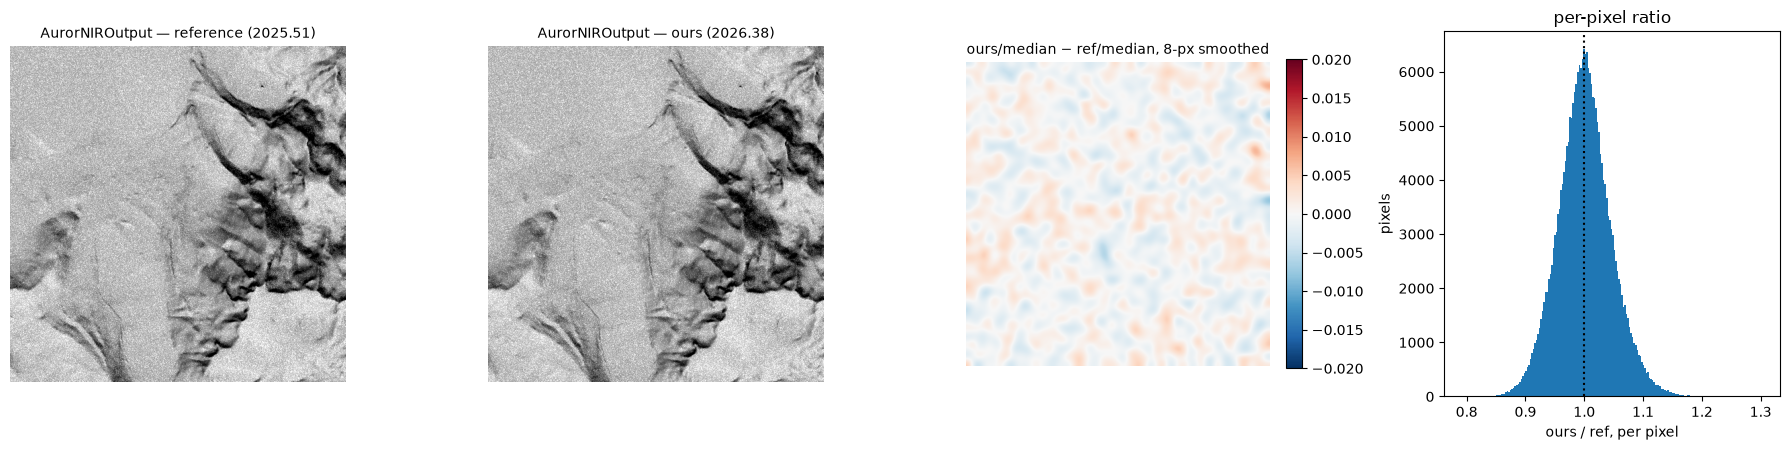

In [14]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, median_filter

ratio = new_rad / ref_rad
r_med = np.median(ratio)
corr = np.corrcoef(new_rad.ravel(), ref_rad.ravel())[0, 1]
nn, nr = new_rad / np.median(new_rad), ref_rad / np.median(ref_rad)
sig_new = np.std(nn - median_filter(nn, 5))
sig_ref = np.std(nr - median_filter(nr, 5))
diff = nn - nr
sig_diff = np.std(diff)
smooth = gaussian_filter(diff, 8)
print(f"median ours / ref radiance : {r_med:.4f}  (IQR {np.percentile(ratio, 25):.4f}..{np.percentile(ratio, 75):.4f}, "
      f"p1..p99 {np.percentile(ratio, 1):.3f}..{np.percentile(ratio, 99):.3f})")
print(f"image means                : ours {new_rad.mean():.4e}, ref {ref_rad.mean():.4e}  -> {new_rad.mean() / ref_rad.mean():.4f}")
print(f"pixel correlation          : r = {corr:.4f}")
rel_rep, rel_ref = np.abs(new_rad / rep_rad - 1), np.abs(ratio - 1)
print(f"|ours/x - 1| median, p99   : vs repeat {np.median(rel_rep):.5f}, {np.percentile(rel_rep, 99):.5f} "
      f"(r = {np.corrcoef(new_rad.ravel(), rep_rad.ravel())[0, 1]:.5f});  vs reference {np.median(rel_ref):.4f}, "
      f"{np.percentile(rel_ref, 99):.4f}")
print(f"per-image noise (fraction) : ours {sig_new:.4f}, ref {sig_ref:.4f} -> expected diff spread {np.hypot(sig_new, sig_ref):.4f}")
print(f"normalised difference      : spread {sig_diff:.4f}; after 8-px Gaussian smoothing, range "
      f"{smooth.min():+.4f}..{smooth.max():+.4f}")
print(f"smoothed-difference std    : {smooth.std():.4f}; white noise of that spread would give "
      f"{sig_diff / (2 * np.sqrt(np.pi) * 8):.4f}")
corr_smooth = np.corrcoef(gaussian_filter(nn, 8).ravel(), gaussian_filter(nr, 8).ravel())[0, 1]
print(f"correlation after smoothing: r = {corr_smooth:.4f}  (spatial structure, noise suppressed)")


fig, ax = plt.subplots(1, 4, figsize=(18, 4.6))
lo, hi = np.percentile(np.concatenate([new_rad.ravel(), ref_rad.ravel()]), [1, 99])
for a_, im, t in [(ax[0], ref_rad, f"reference ({ref_meta['description'].split('DIRSIG ')[1].split(' ')[0]})"),
                  (ax[1], new_rad, "ours (2026.38)")]:
    a_.imshow(im, cmap="gray", vmin=lo, vmax=hi); a_.set_title(f"AurorNIROutput — {t}", fontsize=10); a_.axis("off")
m = ax[2].imshow(smooth, cmap="RdBu_r", vmin=-0.02, vmax=0.02)
ax[2].set_title("ours/median − ref/median, 8-px smoothed", fontsize=10); ax[2].axis("off")
plt.colorbar(m, ax=ax[2], fraction=0.046)
ax[3].hist(ratio.ravel(), bins=200, color="C0"); ax[3].axvline(r_med, color="k", ls=":")
ax[3].set(xlabel="ours / ref, per pixel", ylabel="pixels", title="per-pixel ratio")
plt.tight_layout(); plt.show()

## Where is the vehicle?

The scene exists for one object: a 1500 K body 50 km up, directly under the sensor. So the
cell asks whether either render shows it. That needs an **expected** signal to compare against,
and every input to the estimate comes from the tree:

* vehicle radiance: a 1500 K blackbody (`Gidder_mat`: reflectance 0, so emissivity 1),
  weighted by the channel's Gaussian response (centre 0.85 µm, σ 0.0637 µm);
* ground radiance, a deliberate *under*-estimate because it is direct sun only: reflectance 0.1
  (`gray.ems` emissivity 0.90, `SPECULAR_FRACTION = 0`) × the atmosphere database's own
  exo-atmospheric irradiance × its ground-level solar transmission × cos(36.24°), its stored
  solar zenith, ÷ π;
* fill fraction: the vehicle's **top-down silhouette** (its OBJ triangles rasterised on a 1 cm
  grid) over the 16.3 m pixel at 500 km.

Under-estimating the ground over-estimates the contrast, but only by the sky and path terms. At
200:1 that changes nothing qualitative.

In [15]:
from matplotlib.path import Path as MplPath

with h5py.File(copies["AurorNewAtmosphere"], "r") as f:
    wl = f["SpectralStates/WavelengthSamplesTable"][0]
    E_exo = f["State0/SolarIrradiance"][()]                         # W / (cm^2 um)
    T_sun = f["State0/SolarTransmission"][0]                        # altitude index 0 = ground
resp = np.exp(-0.5 * ((wl - 0.85) / 0.06369914) ** 2)
band = lambda x: np.sum(x * resp) / np.sum(resp)
planck = 1.191042e4 / wl**5 / np.expm1(1.4387769e4 / (wl * 1500.0))   # W / (cm^2 sr um), 1500 K
L_ground = 0.1 / np.pi * E_exo * T_sun * np.cos(np.radians(atm_sun[0]))
contrast = band(planck) / band(L_ground)

faces = [[int(t.split("/")[0]) - 1 for t in ln.split()[1:4]]
         for ln in (geo / "bundles" / "hypersonic" / "hypersonic.obj").open() if ln.startswith("f ")]
gx, gy = np.meshgrid(np.arange(v[:, 0].min(), v[:, 0].max(), 0.01), np.arange(v[:, 1].min(), v[:, 1].max(), 0.01))
pts, inside = np.c_[gx.ravel(), gy.ravel()], np.zeros(gx.size, bool)
for tri in faces:
    p2 = v[tri, :2]
    lo_, hi_ = p2.min(0), p2.max(0)
    sel = ~inside & np.all((pts >= lo_) & (pts <= hi_), axis=1)
    if sel.any():
        inside[sel] |= MplPath(p2).contains_points(pts[sel])
area = inside.sum() * 1e-4
fill = area / (500e3 * 10e-6 / 0.306) ** 2
expected = fill * (contrast - 1)
print(f"band radiance: 1500 K blackbody {band(planck):.3e}, sunlit ground (direct only) {band(L_ground):.3e} "
      f"W/(cm^2 sr um) -> {contrast:.0f}:1")
print(f"vehicle silhouette {area:.2f} m^2 -> fill {fill:.2%} of a 16.3 m pixel")
print(f"expected excess: +{expected:.0%} of one pixel's background, wherever the vehicle falls among the pixels it touches")
print("the boresight passes through the corner shared by pixels 249/250 x 249/250, so the whole excess")
print("lands in that 2x2 block; its SUM is compared, against the noise of a 4-pixel sum:")
for tag, im in [("ours", new_rad), ("ref ", ref_rad)]:
    ex = im / median_filter(im, 9) - 1                     # excess over the local background
    k = np.unravel_index(np.argmax(ex), ex.shape)
    s2 = ex[c - 1:c + 1, c - 1:c + 1].sum()
    print(f"  {tag}: centre 2x2 summed excess {s2:+.1%} (noise of a 4-px sum {2 * np.std(ex):.1%}) "
          f"-> {(expected - s2) / (2 * np.std(ex)):.1f} sigma below +{expected:.0%}; frame-wide max pixel "
          f"{ex.max():+.1%} at {tuple(int(i) for i in k)}")

band radiance: 1500 K blackbody 3.575e-01, sunlit ground (direct only) 1.729e-03 W/(cm^2 sr um) -> 207:1
vehicle silhouette 0.63 m^2 -> fill 0.24% of a 16.3 m pixel
expected excess: +49% of one pixel's background, wherever the vehicle falls among the pixels it touches
the boresight passes through the corner shared by pixels 249/250 x 249/250, so the whole excess
lands in that 2x2 block; its SUM is compared, against the noise of a 4-pixel sum:


  ours: centre 2x2 summed excess -3.1% (noise of a 4-px sum 8.7%) -> 5.9 sigma below +49%; frame-wide max pixel +32.7% at (104, 400)


  ref : centre 2x2 summed excess -7.1% (noise of a 4-px sum 8.7%) -> 6.4 sigma below +49%; frame-wide max pixel +29.5% at (350, 388)


## What the comparison shows, checked rather than asserted

**Expected: what the version change did, all small.**

* **Headers.** Every field matches except the generator string (`2025.51 (822ab24)` →
  `2026.38 (a020954)`): size, units (`electrons/(m^2)`), channel, wavelength, FWHM,
  acquisition time and integration time. The corner geo-points agree to ≤ 2.2 m, about a
  tenth of an 18 m ground pixel.
* **Geometry: same scene, same pose, different sub-pixel sampling.** Both frame centres land
  within about half a metre of `(-400, 400)` in scene ENU, directly under the sensor. So both
  versions read the static pose (`sceneenu`, Euler `(0, 0, π)`) and the geometry the same way.
  Per pixel, our hit points differ from the reference's by **1.3 m median** (≈ 0.07 px),
  p99 3.4 m. The ENU **mean** of those differences is about 1 mm, so this is scatter, not a
  shift or registration error. **The same-version repeat sets the baseline: 91 % of its truth
  pixels are bit-identical to ours (median 0 m), against 1 % for the reference.** So within a
  version the recorded ray per pixel is reproducible, and the version change altered where in
  each pixel it lands. The isolated ~25 m maxima occur in both comparisons, so they come from
  within-version sampling at steep terrain or occlusion edges, not from the version change.
* **Radiometry: unbiased, with a different noise realisation.** The image means agree to better
  than 0.01 %, and the median per-pixel ratio is 1.0001. Per pixel, ours and the reference
  differ by 2.9 % median (r = 0.86). **The repeat differs from ours by only 0.001 % median
  (p99 0.04 %, r = 0.9999)**, so that scatter is not run-to-run variation on one version. It is
  the version change drawing a different Monte Carlo realisation. It behaves exactly like one.
  The difference's spread (0.045) is no larger than two independent ~4 % noise fields would give.
  Its 8-px-smoothed std (0.0016) equals what white noise of that spread leaves. After smoothing,
  the images correlate at r = 0.9997, with no gradient or pattern in the difference map.
  **No systematic radiometric change between the versions is detectable at this noise level.**
* **Determinism, as a side observation.** Two unseeded runs of this version agree to ≈ 4 × 10⁻⁴,
  the same order Phase 4a saw (3.6 × 10⁻⁴). An unseeded run is reproducible on one install,
  but not across versions.

**Run warnings, all accounted for.** `dirsig5` lists materials 11–19 as unused, which confirms
Stage 0's reading that, with the material map disabled, only material 1 and the bundle's
`Gidder_mat` are used. It warns the scene is wider than 10 km (13 × 28 km terrain). It warns
that every curve starting at 0.40 µm is "insufficient" for its internal **0.35–2.55 µm**
spectral grid, which is wider than the 0.41–2.0 µm bandpass that Stage 0 showed every material
covers. The shortfall falls far outside the 0.85 µm channel's Gaussian response.

**Unexplained, and identical in both versions: the vehicle is not in the image.** The
1500 K vehicle should add about +49 % to the 2×2 pixel block it falls in. Both renders show a
*negative* summed excess there (−3 % ours, −7 % reference), about 6σ below expectation, and the
brightest pixel in each frame is a noise excursion at an unrelated location. No truth pixel
reports a hit above 10 km. That is expected at 0.24 % fill, so it adds no evidence either way.
The candidate causes are **not investigated here**, because that means changing the received
configuration, which this notebook only re-runs:

1. the `dynamicinstance`'s `straight` location engine is driven by a time base that puts the
   vehicle elsewhere at task time 0 (at 100 m/s it leaves the ~8 km field at 50 km within about
   40 s of whatever its reference is);
2. emission is not evaluated for this material in these bands (the `DataDriven` temperature,
   or the scene's `features`, which list no thermal band);
3. the bundle placement.

Both versions agree, so this is a property of the received configuration, not of the version
change. Anyone using this tree as a detection reference should resolve it first.

**Not shown here.** Absolute radiometric truth: the atmosphere database belongs to a site in
western New York (Stage 0), and the original used it too. Also not shown: the other
pre-rendered outputs in `jsims/` and `results/`, which have no surviving jsim and are not
comparison targets.

**Provenance.** Nothing under `AUROR_ref/` changed (fingerprinted around both renders). No
`AUROR_ref` file is referenced directly by path. Every input is a byte-identical copy under
`outputs/auror_scene_input/`, except the scene's asset directories, which are read in place
through symlinks. dirfm was used unmodified; its gaps are bridged by the four small subclasses in
Stage 0.